# STARTER

In [3]:
import sys
import pathlib

# Get project root (parent of generation/)
project_root = pathlib.Path().resolve().parent
sys.path.insert(0, str(project_root))

# MANIFESTO

In [7]:
from scripts.utils.logger import logger

In [8]:
logger_params = {
    "main_folder": "/home/think/Desktop/strats",
    "experiment_name": "LSTM_multivariate_2_strats",
    "date": "2025-10-14",
    "iteration": 1,
    "description": (
        "Se entrenara una LSTM con lorenz63 canonico caotico"
        "en modo multivariable 2 (all for all) para las 5 strategies,"
        "el proposito es que podamos dejar una plantilla"
    )
}

In [9]:
exp_folder, manifesto_path = logger(logger_params)
print(f"Experiment folder created at: {exp_folder}")
print(f"Manifesto written to: {manifesto_path}")

Experiment folder created at: /home/think/Desktop/strats/LSTM_multivariate_2_strats_2025-10-14_iter1
Manifesto written to: /home/think/Desktop/strats/LSTM_multivariate_2_strats_2025-10-14_iter1/manifesto.txt


# DATA

In [10]:
from scripts.data_generation.binder import Binder
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scripts.data_generation.tsdg import DynamicalSystem
from sklearn.preprocessing import MinMaxScaler

# --- Data Generation ---
model_name = 'lorenz63'
sigma = 10 
beta = 8/3
rho = 28
params = (sigma, beta, rho)
binder = Binder("scripts.systems.lorenz63", "lorenz63", params)
binder.import_module()      
model_fixed = binder.fixer()
t_span = (0, 500)
t_eval = np.linspace(t_span[0], t_span[1], 50000)
y0 = np.array([0.1, 0.1, 0.1])
ds1 = DynamicalSystem(model_fixed, y0, t_eval, notebook = True)
_ = ds1.solve()

# --- Convert to dataframe ---
sample = ds1.to_dataframe()

# Train and Test Split
Full = sample.values
n_samples = len(Full)

train_size = int(0.60 * n_samples)   # 70% for training
val_size = int(0.20 * n_samples)     # 10% for validation
test_size = n_samples - train_size - val_size  # remaining 20% for testing

train_data = Full[:train_size]
val_data = Full[train_size:train_size+val_size]
test_data = Full[train_size+val_size:]

# --- Scaling ---
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

# # We fit on train but immediately transform test here for simplicity
# test_scaled  = scaler.transform(test_data.reshape(-1, 1)).flatten()
# # If you want the prediction back in original units:
# # yhat = scaler.inverse_transform(yhat_scaled)

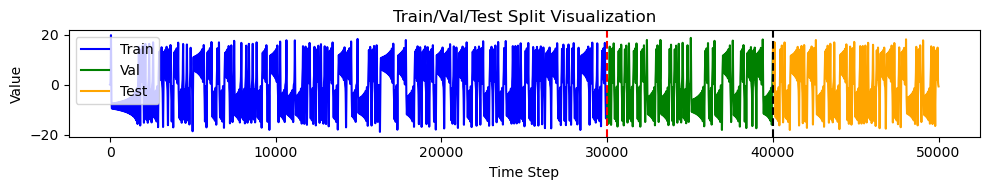

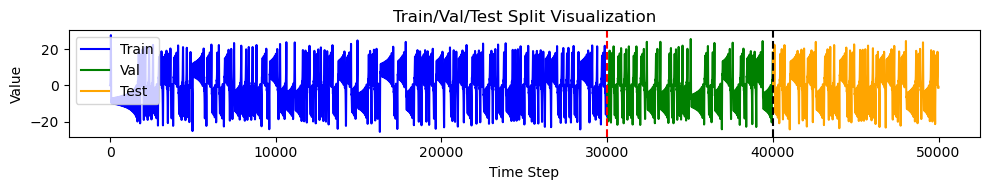

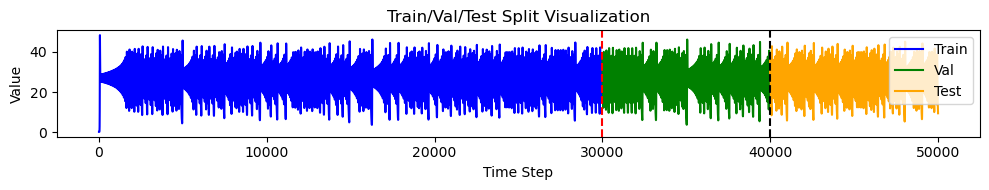

In [11]:
for i in range(len(sample.columns)):
    # Define x-axis ranges based on the lengths
    train_end = len(train_data[:,i])
    val_end = len(train_data[:,i]) + len(val_data[:,i])
    x_train = np.arange(train_end)
    x_val =np.arange(train_end, train_end + len(val_data[:,i]))
    x_test = np.arange(val_end, val_end + len(test_data[:,i]))
    # Plot
    plt.figure(figsize=(10, 2))
    plt.plot(x_train, train_data[:,i], label='Train', color='blue')
    plt.plot(x_val, val_data[:,i], label='Val', color='green')
    plt.plot(x_test, test_data[:,i], label='Test', color='orange')

    # Optional vertical line to indicate the split
    plt.axvline(x=train_end, color='red', linestyle='--') #label='Train/Test Split'
    plt.axvline(x=val_end, color='black', linestyle='--') #label='Train/Test Split'
    plt.legend()
    plt.title("Train/Val/Test Split Visualization")
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.tight_layout()
    plt.show()

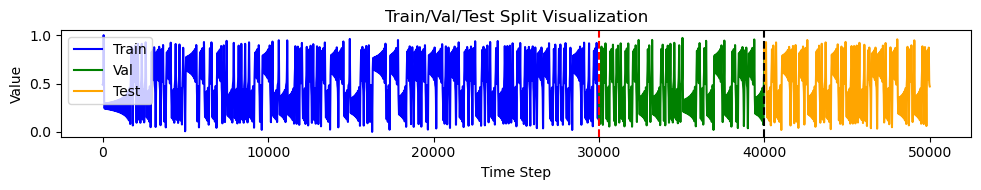

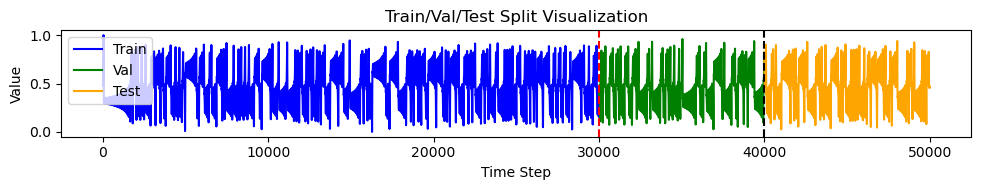

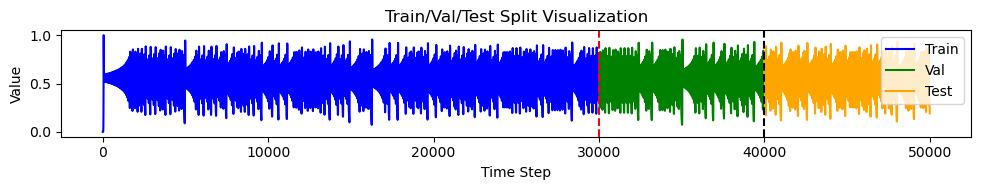

In [12]:
for i in range(len(sample.columns)):
    # Define x-axis ranges based on the lengths
    train_end = len(train_scaled[:,i])
    val_end = len(train_scaled[:,i]) + len(val_scaled[:,i])
    x_train = np.arange(train_end)
    x_val =np.arange(train_end, train_end + len(val_scaled[:,i]))
    x_test = np.arange(val_end, val_end + len(test_scaled[:,i]))
    # Plot
    plt.figure(figsize=(10, 2))
    plt.plot(x_train, train_scaled[:,i], label='Train', color='blue')
    plt.plot(x_val, val_scaled[:,i], label='Val', color='green')
    plt.plot(x_test, test_scaled[:,i], label='Test', color='orange')

    # Optional vertical line to indicate the split
    plt.axvline(x=train_end, color='red', linestyle='--') #label='Train/Test Split'
    plt.axvline(x=val_end, color='black', linestyle='--') #label='Train/Test Split'
    plt.legend()
    plt.title("Train/Val/Test Split Visualization")
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.tight_layout()
    plt.show()

# DATA TREATMENT

### Recursive

In [62]:
from numpy import array

# split a multivariate sequence into samples
def sseq_recursive(sequences, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[end_ix:out_end_ix, :]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [63]:
# choose a number of time steps
n_steps_in, n_steps_out = 1, 1
# convert into input/output
X, y = sseq_recursive(train_scaled, n_steps_in, n_steps_out)

In [64]:
print(f'The X shape is: {X.shape} and the y shape is: {y.shape}')

The X shape is: (2999, 1, 3) and the y shape is: (2999, 1, 3)


### Direct

In [65]:
# split a multivariate sequence into samples
def sseq_direct(sequences, n_steps_in, n_steps_out, skip):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences) - skip:
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[skip + end_ix:out_end_ix + skip , :]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [66]:
n_steps_in = 1
n_steps_out = 1
horizon = 20
datasets = {}
for i in range(horizon):
    skip = i
    X, y = sseq_direct(train_scaled, n_steps_in, n_steps_out, skip)
    X = X.reshape((X.shape[0], X.shape[1], X.shape[2]))
    datasets[i] = (X, y)  # store as tuple

In [67]:
print(f'The X shape is: {X.shape} and the y shape is: {y.shape}')

The X shape is: (2980, 1, 3) and the y shape is: (2980, 1, 3)


In [ ]:
for i in datasets:
    print(i, end=' ')

In [ ]:
X, y = datasets[4]
print(X.shape)
print(y.shape)
for xi, yi in zip(X, y):
    print(xi,yi)

### DiRec

In [ ]:
# split a multivariate sequence into samples
def split_sequences(sequences, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[end_ix:out_end_ix, :]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [ ]:
# choose a number of time steps
n_steps_in, n_steps_out = 2, 2
# convert into input/output
X, y = split_sequences(train_scaled, n_steps_in, n_steps_out)

In [ ]:
for i in range(len(X)):
    print(X[i], y[i])

### MIMO 

In [ ]:
# split a multivariate sequence into samples
def split_sequences(sequences, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[end_ix:out_end_ix, :]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [ ]:
# choose a number of time steps
n_steps_in, n_steps_out = 20, 20
# convert into input/output
X, y = split_sequences(test_scaled, n_steps_in, n_steps_out)

In [ ]:
for i in range(len(X)):
    print(X[i], y[i])

### DirMO

In [ ]:
# split a multivariate sequence into samples
def split_sequences_v1(sequences, n_steps_in, n_steps_out, skip):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences)-skip:
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[skip + end_ix:out_end_ix + skip , :]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [ ]:
n_steps_in = 1
n_steps_out = 2
horizon = 8
skip = n_steps_out
datasets = {}
for i in range(0, horizon, skip):
    X, y = split_sequences_v1(train_scaled, n_steps_in, n_steps_out, i)
    if len(X) == 0:
        raise ValueError(f"Insufficient data points for skip={i}.")
    #X = X.reshape((X.shape[0], X.shape[1], X.shape[2]))
    datasets[i] = (X, y)  # store as tuple

In [ ]:
for i in datasets:
    print(i, end=' ')

In [ ]:
X, y = datasets[0]
print(X.shape)
print(y.shape)
for xi, yi in zip(X, y):
    print(xi,yi)

# RECURSIVE-MULTIVARIATE-ALL_FOR_ALL

### Implementation

In [ ]:
from numpy import array

# split a multivariate sequence into samples
def split_sequences_recursive(sequences, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[end_ix:out_end_ix, :]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)




In [14]:
# choose a number of time steps
n_steps_in, n_steps_out = 1, 1
# convert into input/output
X, y = split_sequences_recursive(train_scaled, n_steps_in, n_steps_out)

In [20]:
print(f'The X shape is: {X.shape} and the y shape is: {y.shape}')

The X shape is: (29999, 1, 3) and the y shape is: (29999, 1, 3)


In [23]:
# the dataset knows the number of featrues, e.g. 2
n_features = X.shape[2]

# multivariate multi-step  encoder-decoder lstm example

from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense
from keras.layers import Reshape

def vanilla_lstm(n_steps_in, n_steps_out, n_features, units=100):
    model = Sequential()
    model.add(LSTM(units, activation='tanh', input_shape=(n_steps_in, n_features)))
    model.add(Dense(n_steps_out * n_features))  # predict all future timesteps × features
    model.add(Reshape((n_steps_out, n_features)))  # reshape to proper output structure
    model.compile(optimizer='adam', loss='mse')
    return model

In [26]:
model_recursive = vanilla_lstm(n_steps_in, n_steps_out, n_features)
model_recursive.fit(X, y, epochs=50, verbose=1)

Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0360
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.3534e-04
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.9624e-05
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.5982e-05
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.3372e-05
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.4590e-06
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.4555e-06
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.4774e-06
Epoch 9/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.2950e-06
Epoch 10/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9.5383e-07
Epoch 11/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.8071e-07
Epoch 12/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.0503e-07
Epoch 13/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6.4021e-07
Epoch 14/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.8626e-07
Epoch

In [ ]:
from sklearn import metrics
from scipy.stats import skew
import numpy as np


def recursive_predictions(starter_sample, horizon, model, scaler = None):
    # Initialize input, start with the last value of the training data
    n_steps_in = starter_sample.shape[0]
    n_features = starter_sample.shape[1]
    uno = starter_sample.reshape((1, n_steps_in, n_features))
    # List to store predictions
    predictions = []
    # Loop to predict one step at a time
    for i in range(horizon):
        yhat_scaled = model.predict(uno, verbose=0)
        # Save prediction in original units
        if scaler is not None:
            yhat_inv = scaler.inverse_transform(yhat_scaled)
            predictions.append(yhat_inv)
        else:
            predictions.append(yhat_scaled)

        # Feed back the scaled value to the model
        uno = yhat_scaled.reshape((1, n_steps_in, n_features)) 
     
    # Convert predictions to numpy array
    predictions = np.array(predictions).squeeze()
    return predictions

In [36]:
starter_sample = train_scaled[-1].reshape((1, n_features))
horizon = 1000
recurs_preds_1 = recursive_predictions(starter_sample, horizon, model_recursive, scaler = None)

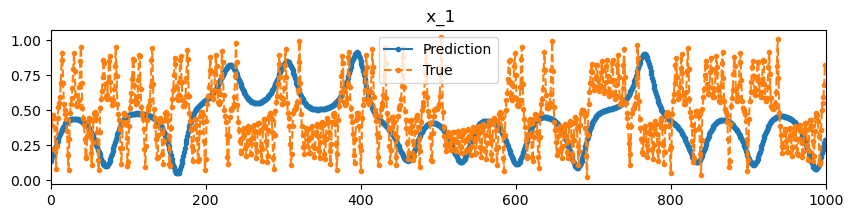

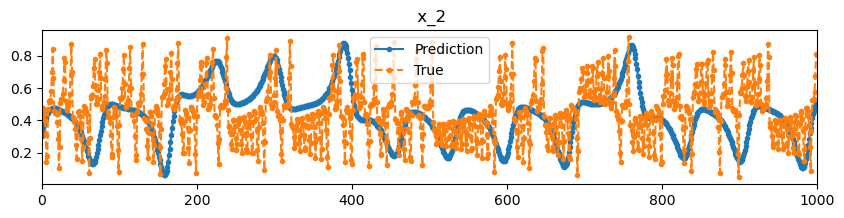

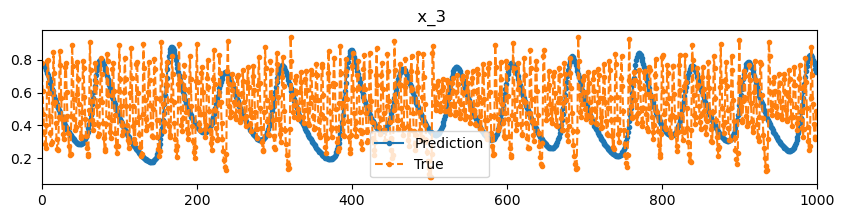

In [58]:
import matplotlib.pyplot as plt

n_features = 3

for i in range(n_features):
    plt.figure(figsize=(10, 2))
    plt.plot(recurs_preds_1[:, i], linestyle='-', marker='.', label='Prediction')
    plt.plot(val_scaled[:1000, i], linestyle='--', marker='.', label='True')
    plt.title(f' x_{i+1}')
    plt.legend()
    plt.xlim(0,1000)
    plt.show()

In [43]:
from scripts.data_generation.binder import Binder
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scripts.data_generation.tsdg import DynamicalSystem
from sklearn.preprocessing import MinMaxScaler

# --- Data Generation ---
model_name = 'lorenz63'
sigma = 10 
beta = 8/3
rho = 28
params = (sigma, beta, rho)
binder = Binder("scripts.systems.lorenz63", "lorenz63", params)
binder.import_module()      
model_fixed = binder.fixer()
t_span = (0, 500)
t_eval = np.linspace(t_span[0], t_span[1], 5000)
y0 = np.array([0.1, 0.1, 0.1])
ds1 = DynamicalSystem(model_fixed, y0, t_eval, notebook = True)
_ = ds1.solve()

# --- Convert to dataframe ---
sample = ds1.to_dataframe()

# Train and Test Split
Full = sample.values
n_samples = len(Full)

train_size = int(0.60 * n_samples)   # 70% for training
val_size = int(0.20 * n_samples)     # 10% for validation
test_size = n_samples - train_size - val_size  # remaining 20% for testing

train_data = Full[:train_size]
val_data = Full[train_size:train_size+val_size]
test_data = Full[train_size+val_size:]

# --- Scaling ---
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

# # We fit on train but immediately transform test here for simplicity
# test_scaled  = scaler.transform(test_data.reshape(-1, 1)).flatten()
# # If you want the prediction back in original units:
# # yhat = scaler.inverse_transform(yhat_scaled)

In [44]:
# choose a number of time steps
n_steps_in, n_steps_out = 1, 1
# convert into input/output
X, y = split_sequences_recursive(train_scaled, n_steps_in, n_steps_out)

In [45]:
print(f'The X shape is: {X.shape} and the y shape is: {y.shape}')

The X shape is: (2999, 1, 3) and the y shape is: (2999, 1, 3)


In [46]:
# the dataset knows the number of featrues, e.g. 2
n_features = X.shape[2]

# multivariate multi-step  encoder-decoder lstm example

from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense
from keras.layers import Reshape

def vanilla_lstm(n_steps_in, n_steps_out, n_features, units=100):
    model = Sequential()
    model.add(LSTM(units, activation='tanh', input_shape=(n_steps_in, n_features)))
    model.add(Dense(n_steps_out * n_features))  # predict all future timesteps × features
    model.add(Reshape((n_steps_out, n_features)))  # reshape to proper output structure
    model.compile(optimizer='adam', loss='mse')
    return model

In [47]:
model_recursive_2 = vanilla_lstm(n_steps_in, n_steps_out, n_features)
model_recursive_2.fit(X, y, epochs=50, verbose=1)

Epoch 1/50


/home/think/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1727
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0209
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0163
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0140
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0134
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0131
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0127
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0117
Epoch 9/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0118
Epoch 10/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0110
Epoch 11/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0111
Epoch 12/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0099
Epoch 13/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0086
Epoch 14/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0079
Epoch 15/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0072
Epoch 16/50
94/94 ━━━━━━━━━━━━

In [48]:
starter_sample = train_scaled[-1].reshape((1, n_features))
horizon = 1000
recurs_preds_2 = recursive_predictions(starter_sample, horizon, model_recursive_2, scaler = None)

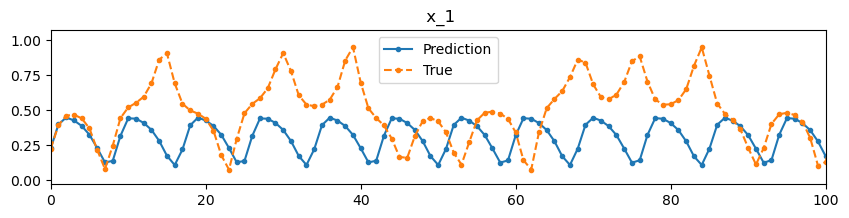

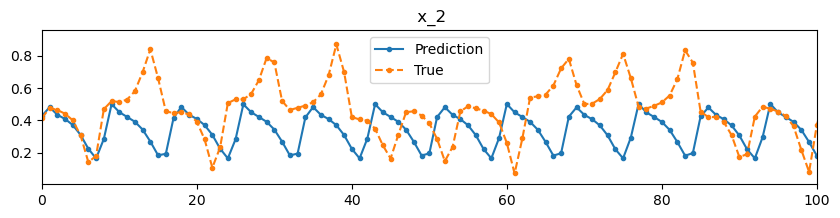

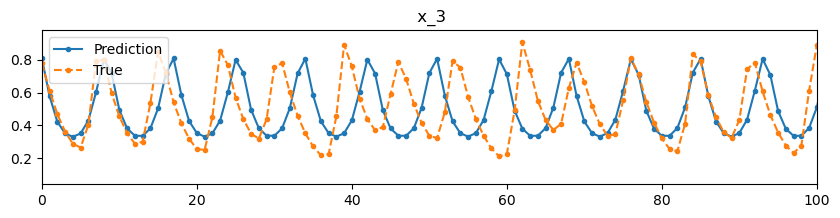

In [54]:
import matplotlib.pyplot as plt

n_features = 3

for i in range(n_features):
    plt.figure(figsize=(10, 2))
    plt.plot(recurs_preds_2[:, i], linestyle='-', marker='.', label='Prediction')
    plt.plot(val_scaled[:1000, i], linestyle='--', marker='.', label='True')
    plt.title(f' x_{i+1}')
    plt.legend()
    plt.xlim(0,100)
    plt.show()


### Error

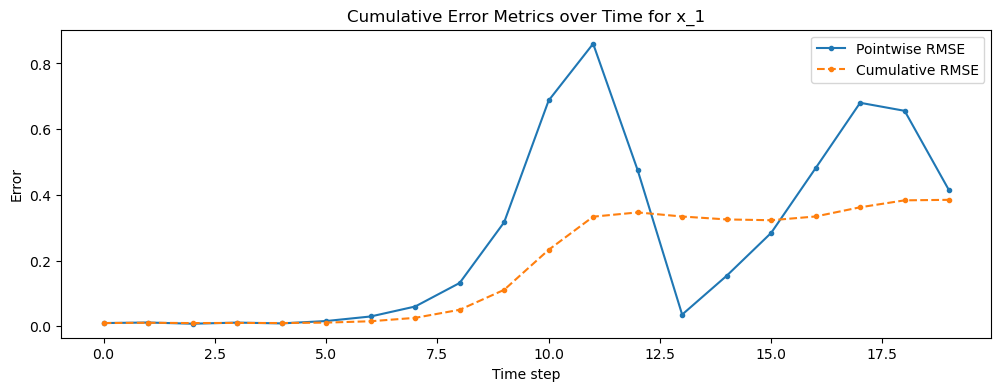

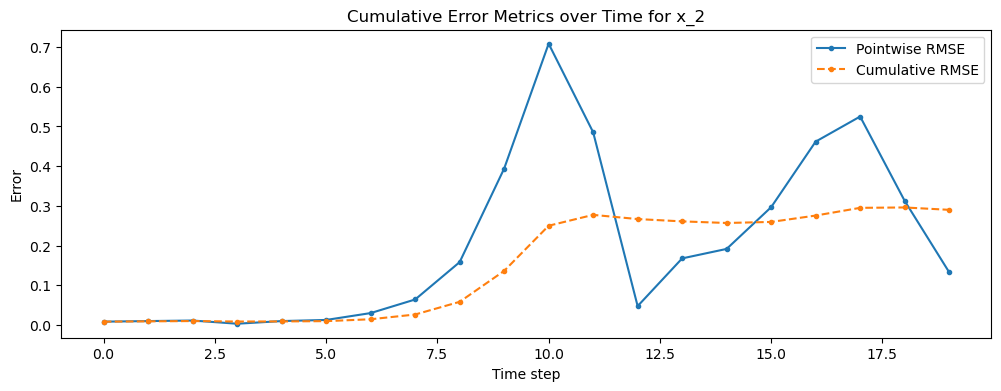

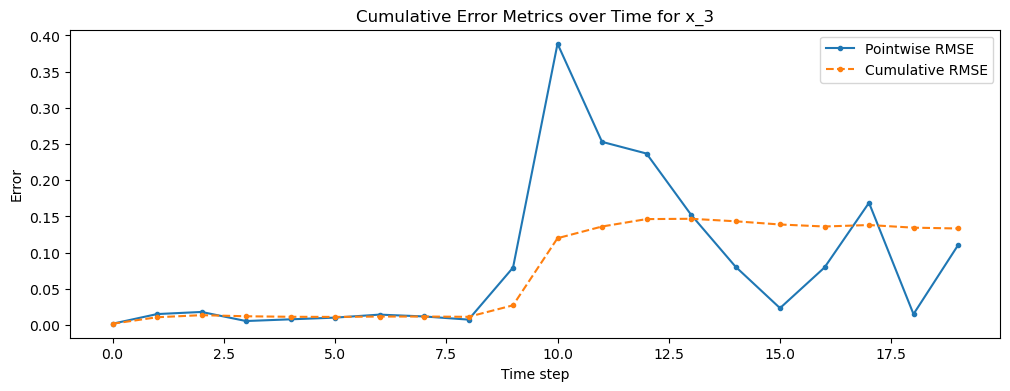

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n_features = 3

for i in range(n_features):

    y_pred = recurs_preds_1[:, i]
    y_true = val_scaled[:20, i]

    # Pointwise errors
    error = y_pred - y_true
    abs_error = np.abs(error)
    
    # Pointwise metrics
    mse_pointwise = error**2
    rmse_pointwise = np.sqrt(mse_pointwise)
    # Avoid divide by zero for percentage errors
    mape_pointwise = np.abs(error / np.where(y_true==0, 1e-8, y_true)) * 100
    maspe_pointwise = np.abs(error / np.where(y_true==0, 1e-8, y_true) - 1)
    
    # Cumulative metrics
    cum_abs_error = np.cumsum(abs_error)
    cum_mse = np.cumsum(mse_pointwise) / (np.arange(len(error)) + 1)
    cum_rmse = np.sqrt(cum_mse)
    cum_mape = np.cumsum(mape_pointwise) / (np.arange(len(error)) + 1)
    cum_maspe = np.cumsum(maspe_pointwise) / (np.arange(len(error)) + 1)
    

    plt.figure(figsize=(12, 4))

    # plt.plot(abs_error, linestyle='-', marker='.', label='Abs Pointwise Error')
    # plt.plot(cum_abs_error, linestyle='--', marker='.', label='Abs Cumulative Error')

    plt.plot(rmse_pointwise, marker='.', linestyle='-', label='Pointwise RMSE')
    plt.plot(cum_rmse, linestyle ='--' , marker = '.',label='Cumulative RMSE')
    
    # plt.plot(mape_pointwise, marker='.', linestyle='--', label='Pointwise MAPE')
    # plt.plot(cum_mape, label='Cumulative MAPE')

    # plt.plot(maspe_pointwise, marker='.', linestyle=':', label='Pointwise MASPE')
    # plt.plot(cum_maspe, linestyle ='--',marker = '.',label='Cumulative MASPE')

    plt.title(f'Cumulative Error Metrics over Time for x_{i+1}')
    plt.xlabel('Time step')
    plt.ylabel('Error')
    plt.legend()
    plt.show()

# DIRECT-MULTIVARIATE-ALL_FOR_ALL

In [246]:
# split a multivariate sequence into samples
def split_sequences_v1(sequences, n_steps_in, n_steps_out, skip):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences) - skip:
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[skip + end_ix:out_end_ix + skip , :]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [247]:
n_steps_in = 1
n_steps_out = 1
horizon = 20
datasets = {}
for i in range(horizon):
    skip = i
    X, y = split_sequences_v1(train_scaled, n_steps_in, n_steps_out, skip)
    X = X.reshape((X.shape[0], X.shape[1], X.shape[2]))
    datasets[i] = (X, y)  # store as tuple

In [248]:
for i in datasets:
    print(i, end=' ')

0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 

In [249]:
X, y = datasets[4]
print(X.shape)
print(y.shape)
for xi, yi in zip(X, y):
    print(xi,yi)

(595, 1, 3)
(595, 1, 3)
[[4.86447589e-01 4.79738719e-01 4.30745881e-04]] [[1.         1.         0.65089077]]
[[0.48986985 0.48666957 0.        ]] [[0.89023684 0.44427998 1.        ]]
[[5.03822071e-01 5.06901295e-01 4.17611642e-04]] [[0.48449624 0.30205179 0.68967235]]
[[0.54943381 0.57203917 0.0087363 ]] [[0.32638191 0.31964645 0.5822419 ]]
[[0.69215139 0.76680912 0.09389267]] [[0.27010655 0.30984922 0.55180352]]
[[1.         1.         0.65089077]] [[0.23275226 0.29136512 0.56664925]]
[[0.89023684 0.44427998 1.        ]] [[0.21071621 0.29309198 0.60586776]]
[[0.48449624 0.30205179 0.68967235]] [[0.21951638 0.31932111 0.62521321]]
[[0.32638191 0.31964645 0.5822419 ]] [[0.24822641 0.34168584 0.60394612]]
[[0.27010655 0.30984922 0.55180352]] [[0.26735656 0.34020663 0.56644388]]
[[0.23275226 0.29136512 0.56664925]] [[0.26087778 0.31865011 0.54457263]]
[[0.21071621 0.29309198 0.60586776]] [[0.23399297 0.29360357 0.55810254]]
[[0.21951638 0.31932111 0.62521321]] [[0.20971677 0.28908312 0.5

In [255]:
# the dataset knows the number of featrues, e.g. 2
n_features = X.shape[2]

# multivariate multi-step  encoder-decoder lstm example

from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense
from keras.layers import Reshape

def vanilla_lstm(n_steps_in, n_steps_out, n_features, units=100):
    model = Sequential()
    model.add(LSTM(units, activation='relu', input_shape=(n_steps_in, n_features)))
    model.add(Dense(n_steps_out * n_features))  # predict all future timesteps × features
    model.add(Reshape((n_steps_out, n_features)))  # reshape to proper output structure
    model.compile(optimizer='adam', loss='mse')
    return model

In [257]:
models = {}
for i, (X, y) in datasets.items():  # i is literally 0, 1, 2...
    model = vanilla_lstm(n_steps_in,n_steps_out, n_features)
    model.fit(X, y, epochs=50, verbose=0)
    models[i] = model  # store the trained model for that step

In [258]:
starter_sample = train_scaled[-1].reshape((1, n_steps_in, n_features))
predictions_direct = []

for i in models:  # skip = number of horizons / models
    model = models[i]
    yhat = model.predict(starter_sample, verbose=0)
    predictions_direct.append(yhat)  # flatten the output

In [260]:
predictions_direct = np.array(predictions_direct).squeeze()

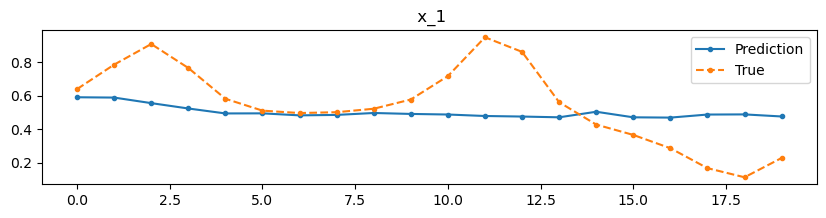

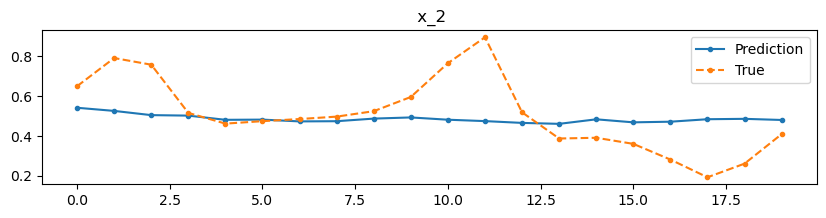

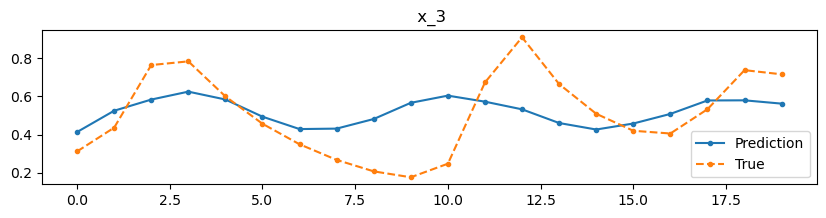

In [261]:
import matplotlib.pyplot as plt

n_features = 3

for i in range(n_features):
    plt.figure(figsize=(10, 2))
    plt.plot(predictions_direct[:, i], linestyle='-', marker='.', label='Prediction')
    plt.plot(val_scaled[:20, i], linestyle='--', marker='.', label='True')
    plt.title(f' x_{i+1}')
    plt.legend()
    plt.show()

### Error

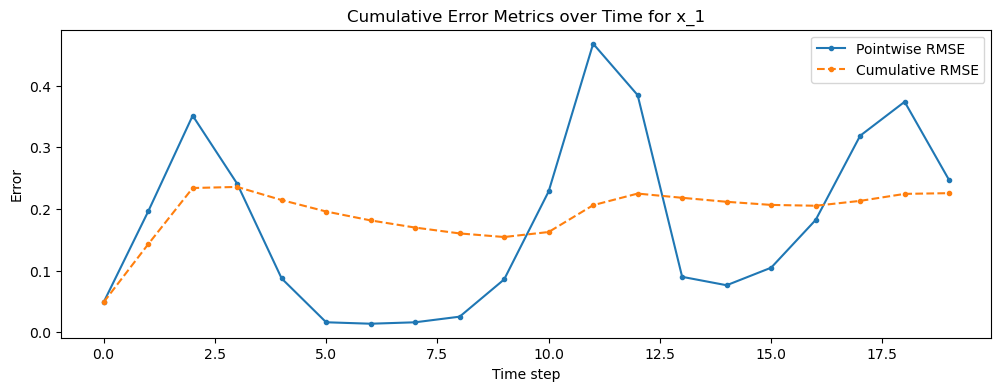

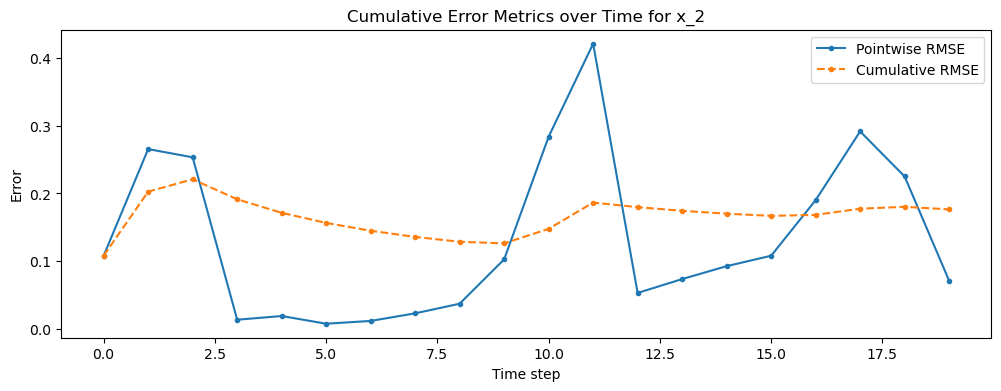

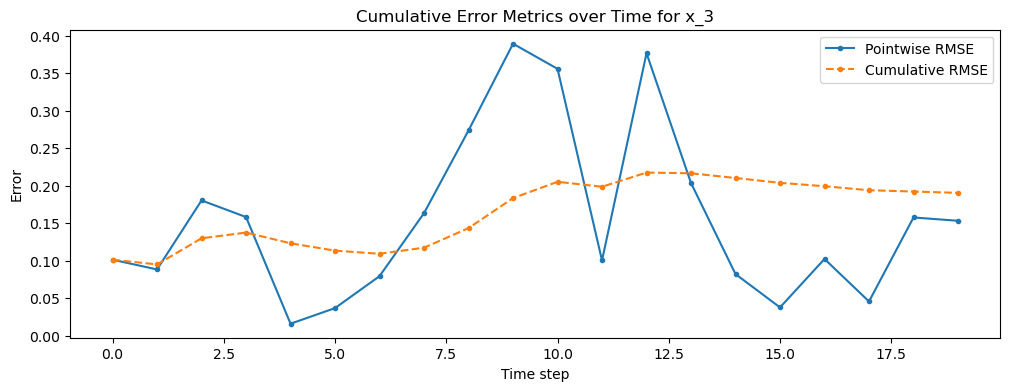

In [264]:
import numpy as np
import matplotlib.pyplot as plt

n_features = 3

for i in range(n_features):

    y_pred = predictions_direct[:, i]
    y_true = val_scaled[:20, i]

    # Pointwise errors
    error = y_pred - y_true
    abs_error = np.abs(error)
    
    # Pointwise metrics
    mse_pointwise = error**2
    rmse_pointwise = np.sqrt(mse_pointwise)
    # Avoid divide by zero for percentage errors
    mape_pointwise = np.abs(error / np.where(y_true==0, 1e-8, y_true)) * 100
    maspe_pointwise = np.abs(error / np.where(y_true==0, 1e-8, y_true) - 1)
    
    # Cumulative metrics
    cum_abs_error = np.cumsum(abs_error)
    cum_mse = np.cumsum(mse_pointwise) / (np.arange(len(error)) + 1)
    cum_rmse = np.sqrt(cum_mse)
    cum_mape = np.cumsum(mape_pointwise) / (np.arange(len(error)) + 1)
    cum_maspe = np.cumsum(maspe_pointwise) / (np.arange(len(error)) + 1)
    

    plt.figure(figsize=(12, 4))

    # plt.plot(abs_error, linestyle='-', marker='.', label='Abs Pointwise Error')
    # plt.plot(cum_abs_error, linestyle='--', marker='.', label='Abs Cumulative Error')

    plt.plot(rmse_pointwise, marker='.', linestyle='-', label='Pointwise RMSE')
    plt.plot(cum_rmse, linestyle ='--' , marker = '.',label='Cumulative RMSE')
    
    # plt.plot(mape_pointwise, marker='.', linestyle='--', label='Pointwise MAPE')
    # plt.plot(cum_mape, label='Cumulative MAPE')

    # plt.plot(maspe_pointwise, marker='.', linestyle=':', label='Pointwise MASPE')
    # plt.plot(cum_maspe, linestyle ='--',marker = '.',label='Cumulative MASPE')

    plt.title(f'Cumulative Error Metrics over Time for x_{i+1}')
    plt.xlabel('Time step')
    plt.ylabel('Error')
    plt.legend()
    plt.show()

# DIREC-MULTIVARIATE-ALL_FOR_ALL
Dividir el horizonte $H$ en bloques $B$ de modo que $H/B = N$. Se entrena un modelo para predecir $B$ pasos, y la predicción del bloque se reutiliza como entrada del siguiente bloque hasta alcanzar $H$. 

In [265]:
# split a multivariate sequence into samples
def split_sequences(sequences, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[end_ix:out_end_ix, :]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [266]:
# choose a number of time steps
n_steps_in, n_steps_out = 2, 2
# convert into input/output
X, y = split_sequences(train_scaled, n_steps_in, n_steps_out)

In [267]:
for i in range(len(X)):
    print(X[i], y[i])

[[4.86447589e-01 4.79738719e-01 4.30745881e-04]
 [4.89869847e-01 4.86669566e-01 0.00000000e+00]] [[5.03822071e-01 5.06901295e-01 4.17611642e-04]
 [5.49433809e-01 5.72039166e-01 8.73629809e-03]]
[[4.89869847e-01 4.86669566e-01 0.00000000e+00]
 [5.03822071e-01 5.06901295e-01 4.17611642e-04]] [[0.54943381 0.57203917 0.0087363 ]
 [0.69215139 0.76680912 0.09389267]]
[[5.03822071e-01 5.06901295e-01 4.17611642e-04]
 [5.49433809e-01 5.72039166e-01 8.73629809e-03]] [[0.69215139 0.76680912 0.09389267]
 [1.         1.         0.65089077]]
[[0.54943381 0.57203917 0.0087363 ]
 [0.69215139 0.76680912 0.09389267]] [[1.         1.         0.65089077]
 [0.89023684 0.44427998 1.        ]]
[[0.69215139 0.76680912 0.09389267]
 [1.         1.         0.65089077]] [[0.89023684 0.44427998 1.        ]
 [0.48449624 0.30205179 0.68967235]]
[[1.         1.         0.65089077]
 [0.89023684 0.44427998 1.        ]] [[0.48449624 0.30205179 0.68967235]
 [0.32638191 0.31964645 0.5822419 ]]
[[0.89023684 0.44427998 1.  

In [268]:
# the dataset knows the number of featrues, e.g. 2
n_features = X.shape[2]

# multivariate multi-step  encoder-decoder lstm example

from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense
from keras.layers import Reshape

def vanilla_lstm(n_steps_in, n_steps_out, n_features, units=100):
    model = Sequential()
    model.add(LSTM(units, activation='relu', input_shape=(n_steps_in, n_features)))
    model.add(Dense(n_steps_out * n_features))  # predict all future timesteps × features
    model.add(Reshape((n_steps_out, n_features)))  # reshape to proper output structure
    model.compile(optimizer='adam', loss='mse')
    return model

In [269]:
model_recursive = vanilla_lstm(n_steps_in, n_steps_out, n_features)
model_recursive.fit(X, y, epochs=800, verbose=0)

In [270]:
# demonstrate prediction
x_input = train_scaled[-2:]
x_input = x_input.reshape((1, n_steps_in, n_features))
yhat = model_recursive.predict(x_input, verbose=0)
print(yhat)

[[[0.63320553 0.63865227 0.31570566]
  [0.77416956 0.7888097  0.41990831]]]


In [271]:
from sklearn import metrics
from scipy.stats import skew
import numpy as np


def recursive_predictions(starter_sample, horizon, model, scaler = None):
    # Initialize input, start with the last value of the training data
    n_steps_in = starter_sample.shape[0]
    n_features = starter_sample.shape[1]
    uno = starter_sample.reshape((1, n_steps_in, n_features))
    # List to store predictions
    predictions = []
    # Loop to predict one step at a time
    for i in range(horizon):
        yhat_scaled = model.predict(uno, verbose=0)
        # Save prediction in original units
        if scaler is not None:
            yhat_inv = scaler.inverse_transform(yhat_scaled)
            predictions.append(yhat_inv)
        else:
            predictions.append(yhat_scaled)

        # Feed back the scaled value to the model
        uno = yhat_scaled.reshape((1, n_steps_in, n_features)) 
     
    # Convert predictions to numpy array
    predictions = np.array(predictions).squeeze()
    return predictions

In [275]:
starter_sample = train_scaled[-2:]
horizon = 20
predictions_direc = recursive_predictions(starter_sample, horizon, model_recursive, scaler = None)

In [277]:
# Flatten the horizon axis (axis 1) while keeping features in columns
predictions_direc = predictions_direc.reshape(-1, predictions_direc.shape[2])  

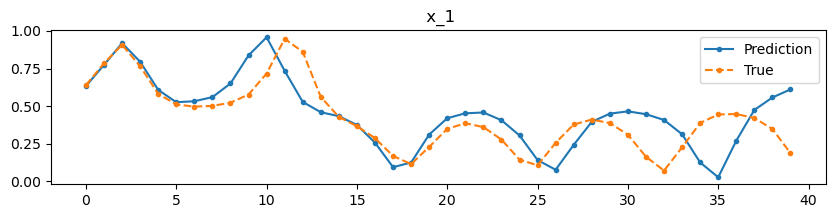

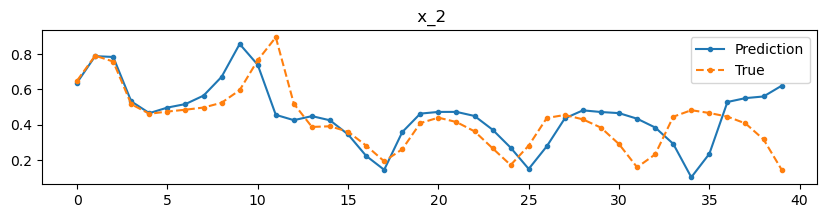

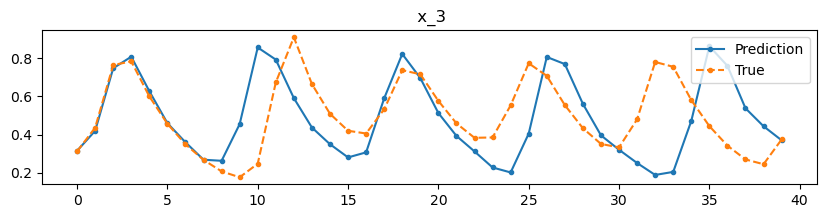

In [278]:
import matplotlib.pyplot as plt

n_features = starter_sample.shape[1]

for i in range(n_features):
    plt.figure(figsize=(10, 2))
    plt.plot(predictions_direc[:, i], linestyle='-', marker='.', label='Prediction')
    plt.plot(val_scaled[:40, i], linestyle='--', marker='.', label='True')
    plt.title(f' x_{i+1}')
    plt.legend()
    plt.show()

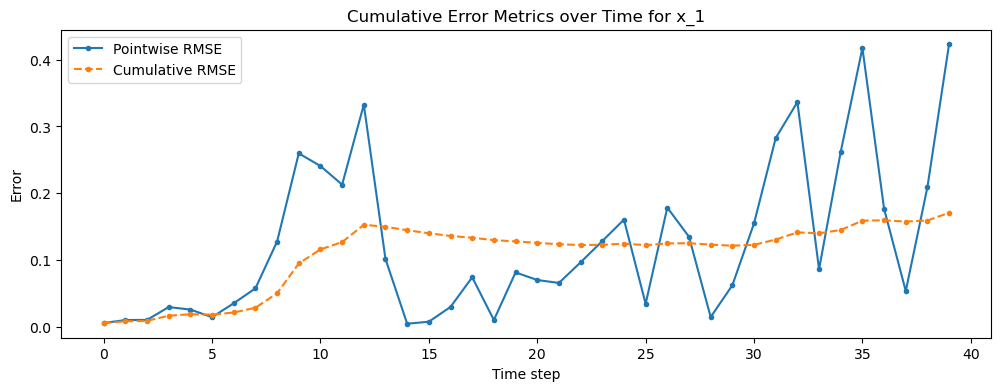

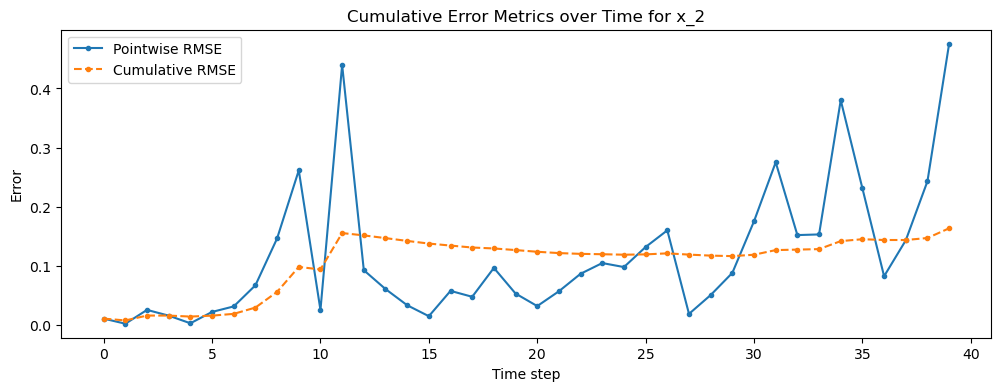

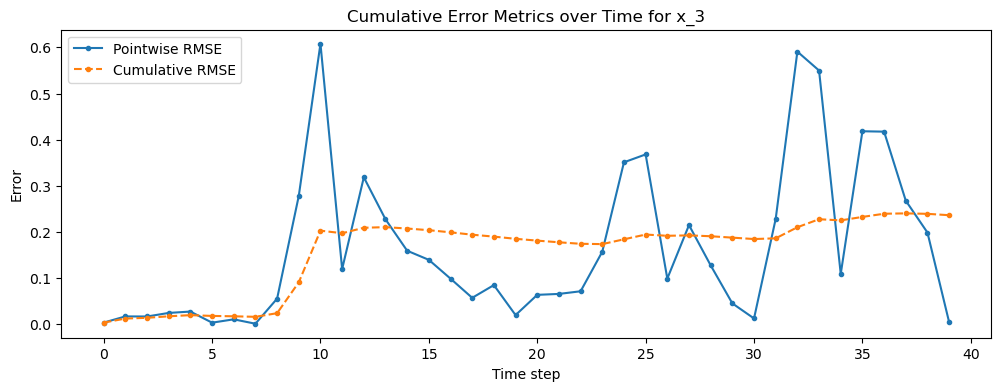

In [280]:
import numpy as np
import matplotlib.pyplot as plt

n_features = 3

for i in range(n_features):

    y_pred = predictions_direc[:, i]
    y_true = val_scaled[:40, i]

    # Pointwise errors
    error = y_pred - y_true
    abs_error = np.abs(error)
    
    # Pointwise metrics
    mse_pointwise = error**2
    rmse_pointwise = np.sqrt(mse_pointwise)
    # Avoid divide by zero for percentage errors
    mape_pointwise = np.abs(error / np.where(y_true==0, 1e-8, y_true)) * 100
    maspe_pointwise = np.abs(error / np.where(y_true==0, 1e-8, y_true) - 1)
    
    # Cumulative metrics
    cum_abs_error = np.cumsum(abs_error)
    cum_mse = np.cumsum(mse_pointwise) / (np.arange(len(error)) + 1)
    cum_rmse = np.sqrt(cum_mse)
    cum_mape = np.cumsum(mape_pointwise) / (np.arange(len(error)) + 1)
    cum_maspe = np.cumsum(maspe_pointwise) / (np.arange(len(error)) + 1)
    

    plt.figure(figsize=(12, 4))

    # plt.plot(abs_error, linestyle='-', marker='.', label='Abs Pointwise Error')
    # plt.plot(cum_abs_error, linestyle='--', marker='.', label='Abs Cumulative Error')

    plt.plot(rmse_pointwise, marker='.', linestyle='-', label='Pointwise RMSE')
    plt.plot(cum_rmse, linestyle ='--' , marker = '.',label='Cumulative RMSE')
    
    # plt.plot(mape_pointwise, marker='.', linestyle='--', label='Pointwise MAPE')
    # plt.plot(cum_mape, label='Cumulative MAPE')

    # plt.plot(maspe_pointwise, marker='.', linestyle=':', label='Pointwise MASPE')
    # plt.plot(cum_maspe, linestyle ='--',marker = '.',label='Cumulative MASPE')

    plt.title(f'Cumulative Error Metrics over Time for x_{i+1}')
    plt.xlabel('Time step')
    plt.ylabel('Error')
    plt.legend()
    plt.show()

# MIMO-MULTIVARIATE-ALL_FOR_ALL

In [281]:
# split a multivariate sequence into samples
def split_sequences(sequences, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[end_ix:out_end_ix, :]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [282]:
# choose a number of time steps
n_steps_in, n_steps_out = 20, 20
# convert into input/output
X, y = split_sequences(test_scaled, n_steps_in, n_steps_out)

In [283]:
for i in range(len(X)):
    print(X[i], y[i])

[[0.34753992 0.45374765 0.59827905]
 [0.40194509 0.43482175 0.46849719]
 [0.39118066 0.39351481 0.37643233]
 [0.32763923 0.31266264 0.3403495 ]
 [0.19736059 0.18552764 0.43955911]
 [0.07758895 0.19365707 0.7267321 ]
 [0.18592066 0.41147511 0.77894921]
 [0.35911786 0.47644428 0.61225437]
 [0.43018844 0.46245787 0.47006284]
 [0.43622611 0.43790884 0.36393055]
 [0.40500213 0.39210149 0.29144302]
 [0.32153987 0.29063314 0.27855921]
 [0.15351502 0.13006804 0.44936847]
 [0.04144834 0.22062651 0.82369322]
 [0.23956545 0.48309182 0.77035246]
 [0.4258563  0.51457162 0.57601581]
 [0.49293609 0.50798839 0.43869853]
 [0.52159613 0.52153887 0.33867037]
 [0.56172516 0.56734414 0.27199902]
 [0.6526745  0.67645505 0.26849431]] [[0.83212894 0.8422737  0.46947661]
 [0.92744307 0.71141413 0.85103459]
 [0.70476579 0.45540559 0.75708462]
 [0.52384983 0.43417559 0.56367645]
 [0.45957853 0.4370129  0.43099192]
 [0.42465117 0.41291829 0.33723808]
 [0.36613946 0.34491714 0.28736964]
 [0.24064657 0.20612173 0.3

In [284]:
# the dataset knows the number of featrues, e.g. 2
n_features = X.shape[2]

# multivariate multi-step  encoder-decoder lstm example

from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense
from keras.layers import Reshape

def vanilla_lstm(n_steps_in, n_steps_out, n_features, units=100):
    model = Sequential()
    model.add(LSTM(units, activation='relu', input_shape=(n_steps_in, n_features)))
    model.add(Dense(n_steps_out * n_features))  # predict all future timesteps × features
    model.add(Reshape((n_steps_out, n_features)))  # reshape to proper output structure
    model.compile(optimizer='adam', loss='mse')
    return model

In [285]:
model_MIMO = vanilla_lstm(n_steps_in, n_steps_out, n_features)
model_MIMO.fit(X, y, epochs=800, verbose=0)

/home/think/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [286]:
# demonstrate prediction
x_input = test_scaled[-20:]
x_input = x_input.reshape((1, n_steps_in, n_features))
predictions_MIMO = model_MIMO.predict(x_input, verbose=0)
print(predictions_MIMO)

[[[0.75598323 0.71935725 0.5231668 ]
  [0.8300099  0.72134423 0.54190356]
  [0.7976097  0.6509994  0.49288407]
  [0.7238028  0.57552767 0.5011638 ]
  [0.6380058  0.50382817 0.51665294]
  [0.5678414  0.50022733 0.5546694 ]
  [0.46917978 0.40616694 0.51166755]
  [0.36661822 0.36156657 0.48395032]
  [0.31853732 0.2940936  0.4685948 ]
  [0.21134098 0.2130627  0.51492834]
  [0.12235852 0.25374958 0.54405355]
  [0.20310852 0.36089548 0.57802534]
  [0.32337627 0.47309393 0.53669834]
  [0.4540161  0.5002206  0.4499312 ]
  [0.4550053  0.52156055 0.39244974]
  [0.48130283 0.49025577 0.3340099 ]
  [0.53043544 0.46617803 0.33267573]
  [0.43611297 0.46164086 0.32456955]
  [0.41627786 0.41074026 0.30523992]
  [0.4078661  0.37533486 0.41111717]]]


In [287]:
predictions_MIMO = predictions_MIMO.squeeze()

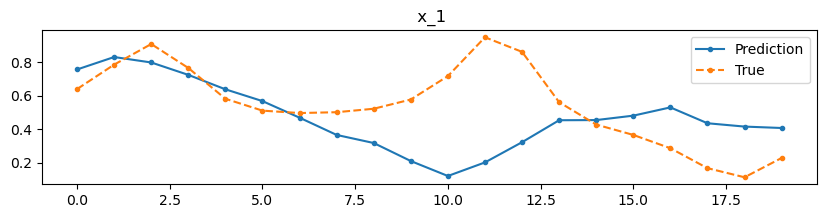

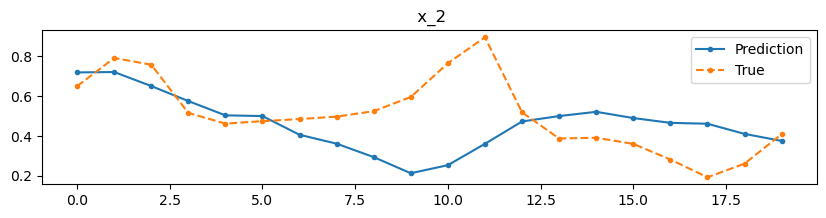

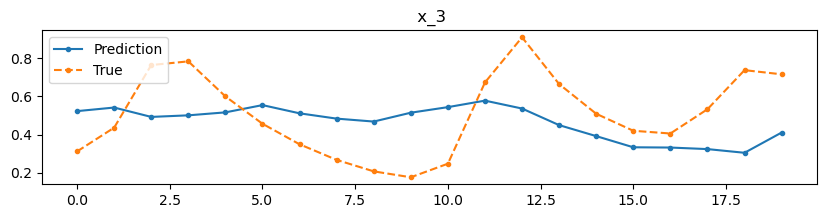

In [288]:
import matplotlib.pyplot as plt

n_features = 3

for i in range(n_features):
    plt.figure(figsize=(10, 2))
    plt.plot(predictions_MIMO[:, i], linestyle='-', marker='.', label='Prediction')
    plt.plot(val_scaled[:20, i], linestyle='--', marker='.', label='True')
    plt.title(f' x_{i+1}')
    plt.legend()
    plt.show()

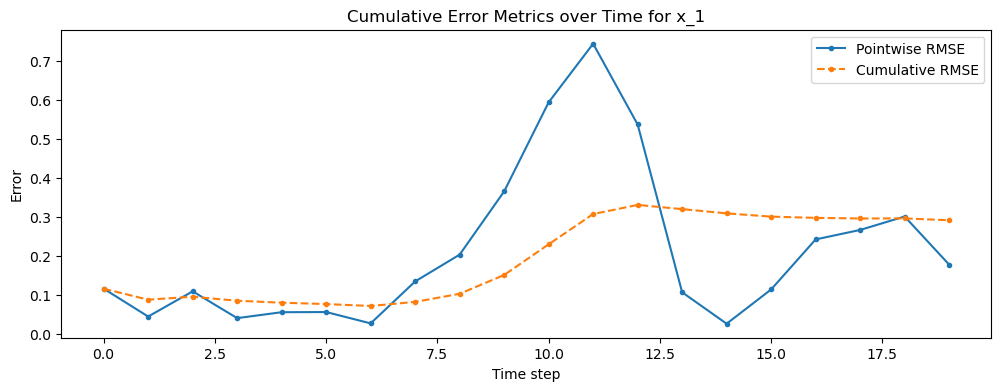

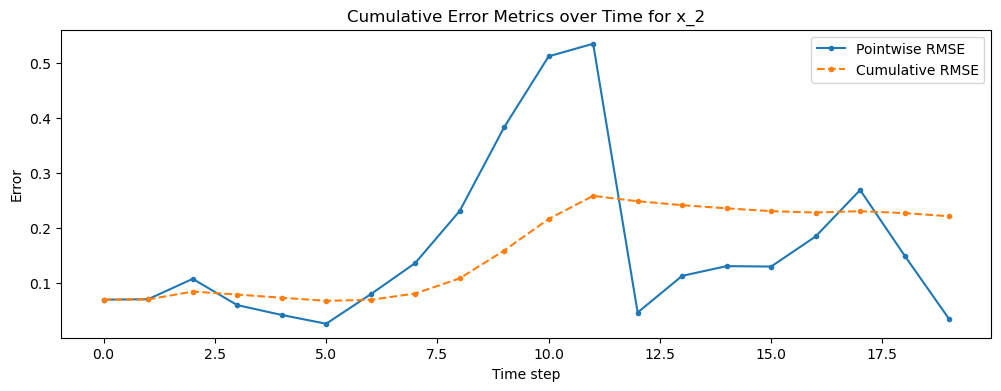

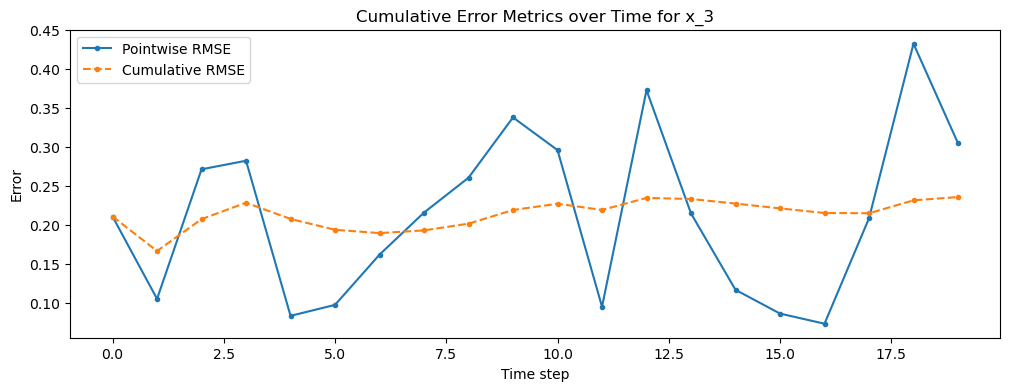

In [289]:
import numpy as np
import matplotlib.pyplot as plt

n_features = 3

for i in range(n_features):

    y_pred = predictions_MIMO[:, i]
    y_true = val_scaled[:20, i]

    # Pointwise errors
    error = y_pred - y_true
    abs_error = np.abs(error)
    
    # Pointwise metrics
    mse_pointwise = error**2
    rmse_pointwise = np.sqrt(mse_pointwise)
    # Avoid divide by zero for percentage errors
    mape_pointwise = np.abs(error / np.where(y_true==0, 1e-8, y_true)) * 100
    maspe_pointwise = np.abs(error / np.where(y_true==0, 1e-8, y_true) - 1)
    
    # Cumulative metrics
    cum_abs_error = np.cumsum(abs_error)
    cum_mse = np.cumsum(mse_pointwise) / (np.arange(len(error)) + 1)
    cum_rmse = np.sqrt(cum_mse)
    cum_mape = np.cumsum(mape_pointwise) / (np.arange(len(error)) + 1)
    cum_maspe = np.cumsum(maspe_pointwise) / (np.arange(len(error)) + 1)
    

    plt.figure(figsize=(12, 4))

    # plt.plot(abs_error, linestyle='-', marker='.', label='Abs Pointwise Error')
    # plt.plot(cum_abs_error, linestyle='--', marker='.', label='Abs Cumulative Error')

    plt.plot(rmse_pointwise, marker='.', linestyle='-', label='Pointwise RMSE')
    plt.plot(cum_rmse, linestyle ='--' , marker = '.',label='Cumulative RMSE')
    
    # plt.plot(mape_pointwise, marker='.', linestyle='--', label='Pointwise MAPE')
    # plt.plot(cum_mape, label='Cumulative MAPE')

    # plt.plot(maspe_pointwise, marker='.', linestyle=':', label='Pointwise MASPE')
    # plt.plot(cum_maspe, linestyle ='--',marker = '.',label='Cumulative MASPE')

    plt.title(f'Cumulative Error Metrics over Time for x_{i+1}')
    plt.xlabel('Time step')
    plt.ylabel('Error')
    plt.legend()
    plt.show()

# DIRMO-MULTIVARIATE-ALL_FOR_ALL
Dividir el horizonte $H$ en bloques $B$ de modo que $H/B = N$, y entrenar $N$ modelos, cada uno encargado de predecir $B$ pasos consecutivos. 

In [290]:
# split a multivariate sequence into samples
def split_sequences_v1(sequences, n_steps_in, n_steps_out, skip):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences)-skip:
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[skip + end_ix:out_end_ix + skip , :]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [291]:
n_steps_in = 1
n_steps_out = 2
horizon = 8
skip = n_steps_out
datasets = {}
for i in range(0, horizon, skip):
    X, y = split_sequences_v1(train_scaled, n_steps_in, n_steps_out, i)
    if len(X) == 0:
        raise ValueError(f"Insufficient data points for skip={i}.")
    #X = X.reshape((X.shape[0], X.shape[1], X.shape[2]))
    datasets[i] = (X, y)  # store as tuple

In [292]:
for i in datasets:
    print(i, end=' ')

0 2 4 6 

In [293]:
X, y = datasets[0]
print(X.shape)
print(y.shape)
for xi, yi in zip(X, y):
    print(xi,yi)

(598, 1, 3)
(598, 2, 3)
[[4.86447589e-01 4.79738719e-01 4.30745881e-04]] [[4.89869847e-01 4.86669566e-01 0.00000000e+00]
 [5.03822071e-01 5.06901295e-01 4.17611642e-04]]
[[0.48986985 0.48666957 0.        ]] [[5.03822071e-01 5.06901295e-01 4.17611642e-04]
 [5.49433809e-01 5.72039166e-01 8.73629809e-03]]
[[5.03822071e-01 5.06901295e-01 4.17611642e-04]] [[0.54943381 0.57203917 0.0087363 ]
 [0.69215139 0.76680912 0.09389267]]
[[0.54943381 0.57203917 0.0087363 ]] [[0.69215139 0.76680912 0.09389267]
 [1.         1.         0.65089077]]
[[0.69215139 0.76680912 0.09389267]] [[1.         1.         0.65089077]
 [0.89023684 0.44427998 1.        ]]
[[1.         1.         0.65089077]] [[0.89023684 0.44427998 1.        ]
 [0.48449624 0.30205179 0.68967235]]
[[0.89023684 0.44427998 1.        ]] [[0.48449624 0.30205179 0.68967235]
 [0.32638191 0.31964645 0.5822419 ]]
[[0.48449624 0.30205179 0.68967235]] [[0.32638191 0.31964645 0.5822419 ]
 [0.27010655 0.30984922 0.55180352]]
[[0.32638191 0.31964645 

In [294]:
# the dataset knows the number of featrues, e.g. 2
n_features = X.shape[2]

In [295]:
# multivariate multi-step  encoder-decoder lstm example

from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense
from keras.layers import Reshape

def vanilla_lstm(n_steps_in, n_steps_out, n_features, units=100):
    model = Sequential()
    model.add(LSTM(units, activation='relu', input_shape=(n_steps_in, n_features)))
    model.add(Dense(n_steps_out * n_features))  # predict all future timesteps × features
    model.add(Reshape((n_steps_out, n_features)))  # reshape to proper output structure
    model.compile(optimizer='adam', loss='mse')
    return model

In [303]:
models_DIRMO = {}
for i, (X, y) in datasets.items():  # i is literally 0, 1, 2...
    model = vanilla_lstm(n_steps_in,n_steps_out, n_features)
    model.fit(X, y, epochs=500, verbose=0)
    models_DIRMO[i] = model  # store the trained model for that step

/home/think/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [307]:
starter_sample = train_scaled[-1].reshape((1, n_steps_in, n_features)) 
predictions_DIRMO = []

for i in models_DIRMO:  # skip = number of horizons / models
    model = models_DIRMO[i]
    yhat = model.predict(starter_sample, verbose=0)
    predictions_DIRMO.append(yhat)  # flatten the output

In [308]:
predictions_DIRMO = np.array(predictions_DIRMO).squeeze()
predictions_DIRMO = predictions_DIRMO.reshape(-1, predictions_DIRMO.shape[2])  

In [309]:
predictions_DIRMO

array([[0.63589954, 0.65680814, 0.30440414],
       [0.7932416 , 0.786124  , 0.3973659 ],
       [0.8557534 , 0.7028695 , 0.65480936],
       [0.7783472 , 0.6012171 , 0.6742759 ],
       [0.6077972 , 0.51806843, 0.62211263],
       [0.5510448 , 0.50115263, 0.5470804 ],
       [0.57800496, 0.5428399 , 0.43831316],
       [0.5885925 , 0.55081296, 0.36805505]], dtype=float32)

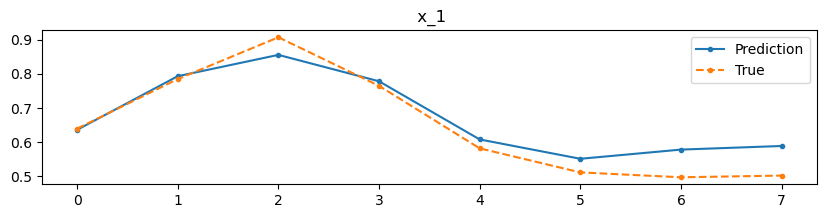

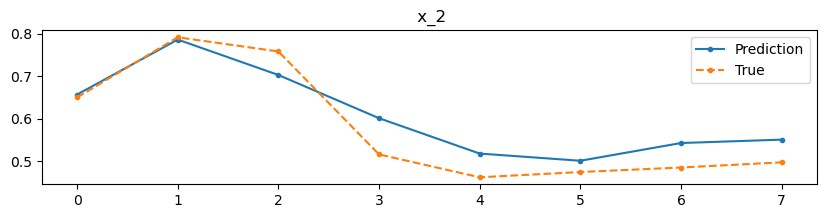

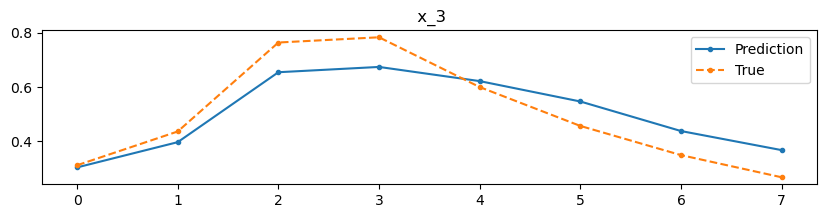

In [310]:
import matplotlib.pyplot as plt

n_features = 3

for i in range(n_features):
    plt.figure(figsize=(10, 2))
    plt.plot(predictions_DIRMO[:, i], linestyle='-', marker='.', label='Prediction')
    plt.plot(val_scaled[:8, i], linestyle='--', marker='.', label='True')
    plt.title(f' x_{i+1}')
    plt.legend()
    plt.show()

### Error

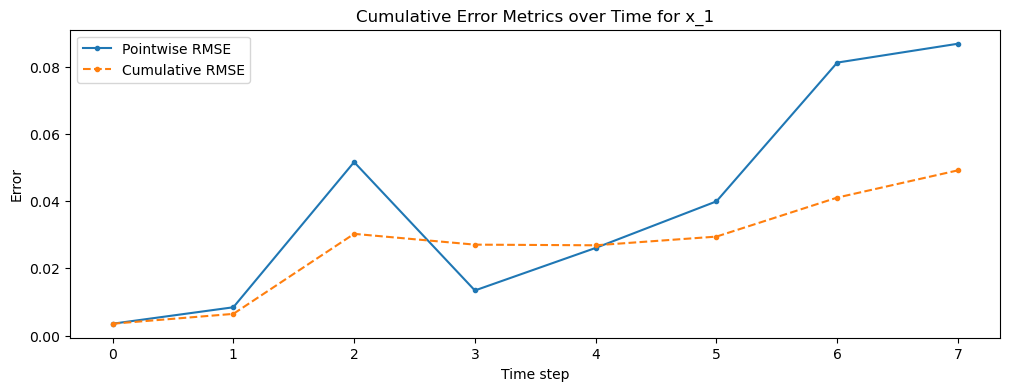

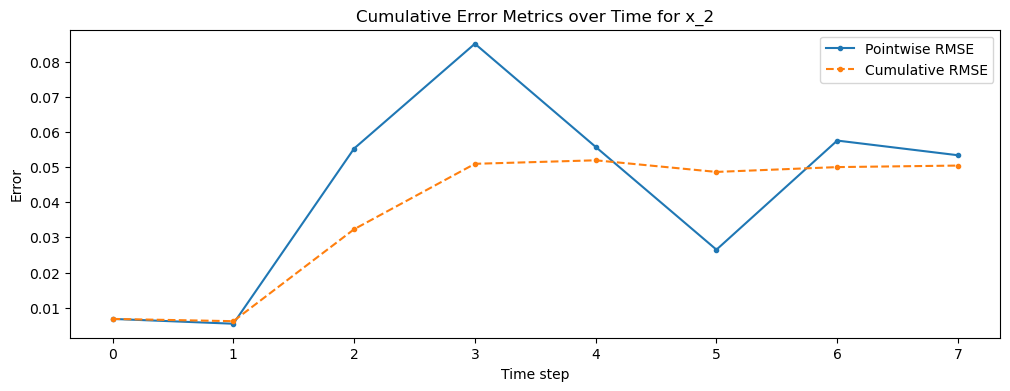

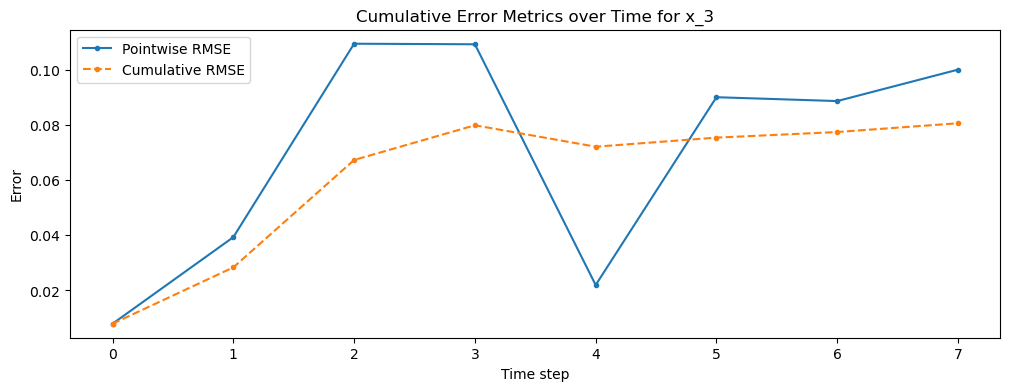

In [311]:
import numpy as np
import matplotlib.pyplot as plt

n_features = 3

for i in range(n_features):

    y_pred = predictions_DIRMO[:, i]
    y_true = val_scaled[:8, i]

    # Pointwise errors
    error = y_pred - y_true
    abs_error = np.abs(error)
    
    # Pointwise metrics
    mse_pointwise = error**2
    rmse_pointwise = np.sqrt(mse_pointwise)
    # Avoid divide by zero for percentage errors
    mape_pointwise = np.abs(error / np.where(y_true==0, 1e-8, y_true)) * 100
    maspe_pointwise = np.abs(error / np.where(y_true==0, 1e-8, y_true) - 1)
    
    # Cumulative metrics
    cum_abs_error = np.cumsum(abs_error)
    cum_mse = np.cumsum(mse_pointwise) / (np.arange(len(error)) + 1)
    cum_rmse = np.sqrt(cum_mse)
    cum_mape = np.cumsum(mape_pointwise) / (np.arange(len(error)) + 1)
    cum_maspe = np.cumsum(maspe_pointwise) / (np.arange(len(error)) + 1)
    

    plt.figure(figsize=(12, 4))

    # plt.plot(abs_error, linestyle='-', marker='.', label='Abs Pointwise Error')
    # plt.plot(cum_abs_error, linestyle='--', marker='.', label='Abs Cumulative Error')

    plt.plot(rmse_pointwise, marker='.', linestyle='-', label='Pointwise RMSE')
    plt.plot(cum_rmse, linestyle ='--' , marker = '.',label='Cumulative RMSE')
    
    # plt.plot(mape_pointwise, marker='.', linestyle='--', label='Pointwise MAPE')
    # plt.plot(cum_mape, label='Cumulative MAPE')

    # plt.plot(maspe_pointwise, marker='.', linestyle=':', label='Pointwise MASPE')
    # plt.plot(cum_maspe, linestyle ='--',marker = '.',label='Cumulative MASPE')

    plt.title(f'Cumulative Error Metrics over Time for x_{i+1}')
    plt.xlabel('Time step')
    plt.ylabel('Error')
    plt.legend()
    plt.show()